**Name: Kaustubh Aswale**  
**Roll No: 69** 
**Assignment 5**

1. Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv
dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given
dataset.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [41]:
df = pd.read_csv("Social_Network_Ads.csv")

In [42]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (400, 5)

Columns:
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

Data Types:
 User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


In [43]:
numeric_cols = ["Age", "EstimatedSalary"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

print("\nMissing Values After Injection:\n", df.isnull().sum())


Missing Values After Injection:
 User ID             0
Gender              0
Age                20
EstimatedSalary    20
Purchased           0
dtype: int64


In [44]:
# Summary statistics
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  380.000000       380.000000  400.000000
mean   1.569154e+07   37.565789     70126.315789    0.357500
std    7.165832e+04   10.445152     34412.979114    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   45.250000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [45]:
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nTarget Distribution:\n", df["Purchased"].value_counts())



Gender Distribution:
 Gender
Female    204
Male      196
Name: count, dtype: int64

Target Distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


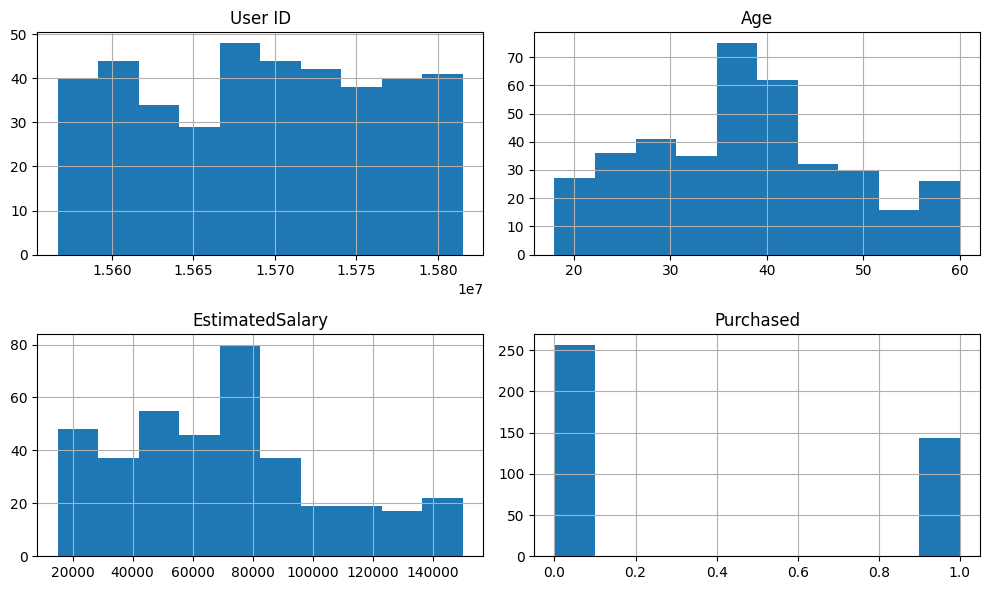

In [46]:
# Histograms
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


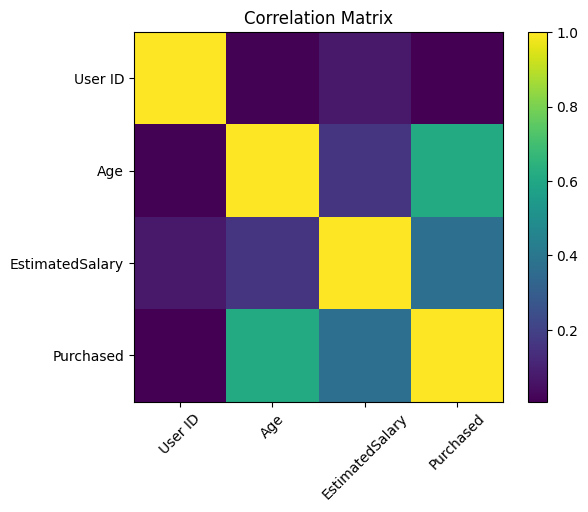

In [47]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [48]:
print(df.columns)

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')


Number of outliers detected: 0


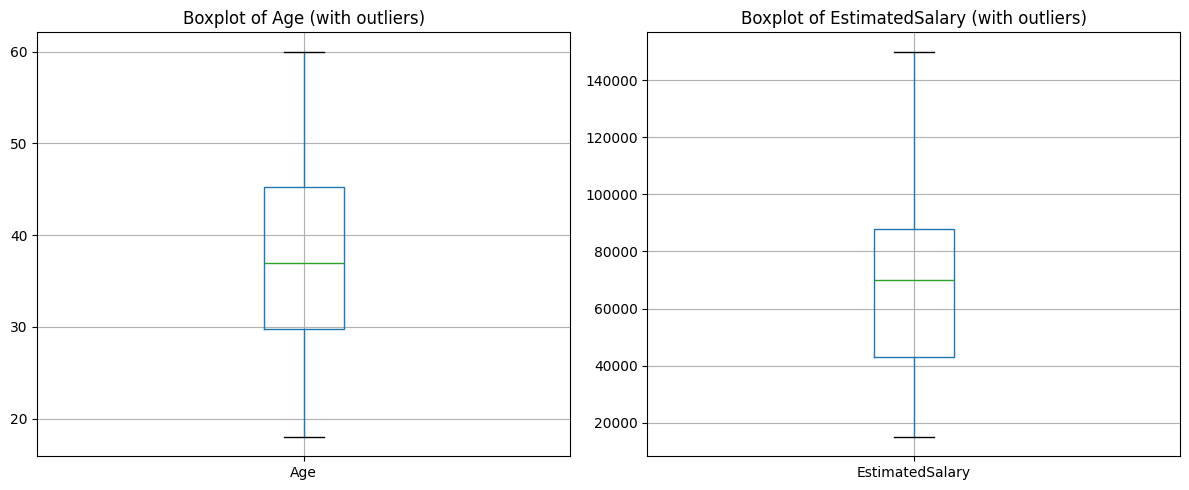

Original dataset shape: (400, 5)
Cleaned dataset shape: (400, 5)
Removed 0 outliers

Missing Values After Imputation:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
dtype: int64


In [49]:
# Outlier Detection and Removal using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)].index
    return outliers

# Detect outliers in numeric columns
outlier_indices = set()
for col in ['Age', 'EstimatedSalary']:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers)

print(f"Number of outliers detected: {len(outlier_indices)}")

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot of Age (with outliers)')
df.boxplot(column='EstimatedSalary', ax=axes[1])
axes[1].set_title('Boxplot of EstimatedSalary (with outliers)')
plt.tight_layout()
plt.show()

# Remove outliers
df_clean = df.drop(outlier_indices)
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Removed {len(outlier_indices)} outliers")

df = df_clean

# ==============================
# DEFINE X and y
# ==============================

X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# ==============================
# HANDLE MISSING VALUES
# ==============================

imputer = SimpleImputer(strategy='mean')

num_cols = X.select_dtypes(include=['number']).columns
X[num_cols] = imputer.fit_transform(X[num_cols])

print("\nMissing Values After Imputation:\n", X.isnull().sum())

In [50]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# ==============================
# HANDLE MISSING VALUES
# ==============================

imputer = SimpleImputer(strategy='mean')

num_cols = X.select_dtypes(include=['number']).columns
X[num_cols] = imputer.fit_transform(X[num_cols])

print("\nMissing Values After Imputation:\n", X.isnull().sum())


Missing Values After Imputation:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
dtype: int64


In [52]:
# Encode Gender
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nPreprocessing Completed Successfully!")


Preprocessing Completed Successfully!


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [55]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Confusion Matrix:
 [[65  3]
 [11 21]]

TP: 21
TN: 65
FP: 3
FN: 11

Accuracy: 0.86
Error Rate: 0.14
Precision: 0.875
Recall: 0.65625
